<h1 style='color:red'>Missing Category Imputation</h1>

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as pyplot 

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv('train.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])
df.sample(5)

,FireplaceQu,GarageQual,SalePrice
611,TA,TA,148000
995,NaN,TA,121600
574,NaN,TA,139000
1337,NaN,NaN,52500
345,Gd,TA,140200


In [4]:
df.isnull().mean()*100   
# 'FireplaceQu' has approx 47% missing values and 'GarageQual' has approx 5.5% missing values

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

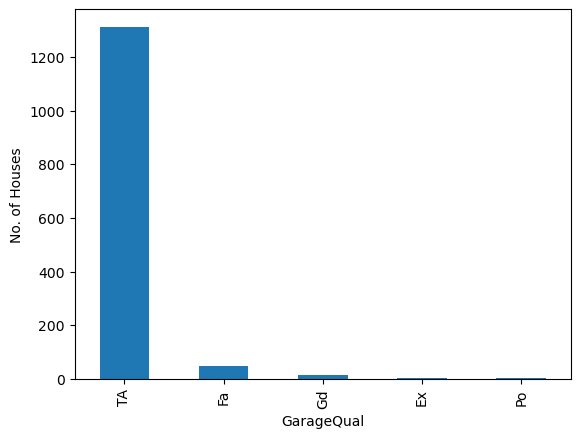

In [5]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot(kind='bar')     
pyplot.xlabel('GarageQual')
pyplot.ylabel('No. of Houses')
pyplot.show()

# there are some missing values also, which is not shown in barplot

<h4 style='color:gold'>Pandas fillna() function </h4>

In [12]:
# imputing Missing Values with 'Missing' category
df['GarageQual'] = df['GarageQual'].fillna('Missing')

<Axes: xlabel='GarageQual'>

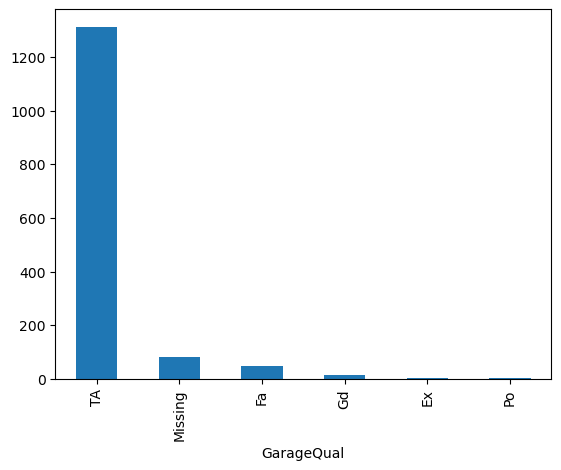

In [13]:
df['GarageQual'].value_counts().plot(kind='bar')

<h2 style="color:purple">Applying SimpleImputer of sklearn</h2>

In [19]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df['SalePrice'], test_size=0.25, random_state=0) 
X_train.shape, X_test.shape

((1095, 2), (365, 2))

In [20]:
imputer = SimpleImputer(strategy='constant', fill_value='Missing')          # imputing by 'Missing' Category

X_train_imp = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [22]:
imputer.statistics_     

array(['Missing', 'Missing'], dtype=object)